In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("7.smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.shape

(2240, 22)

In [7]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# DATA PREPROCESSING

# HANDLE MISSING VALUES

In [8]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# FEATURE ENGINEERING

In [10]:
# 1 age
df["Age"]=2026-df["Year_Birth"]

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [12]:
#2 calculating total tenure of the customers
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)# converting Dt_Customer to date time in pandas and then marking day first as true because pandas follows m-d-y

reference_date=df["Dt_Customer"].max()

df["Customers_Tenure_Days"]=reference_date-df["Dt_Customer"]

In [13]:
# 3 spending
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]


In [14]:
# children
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [15]:
# edution
df["Education"].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate","Master":"Postgraduate"
})

In [16]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [17]:
# marital status
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone","Widow":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})

In [18]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

# DROP COLUMNS

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spending,Total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663 days,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113 days,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312 days,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139 days,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161 days,422,1,Partner


In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customers_Tenure_Days',
       'Total_spending', 'Total_children', 'Living_with'],
      dtype='object')

In [21]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols + spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [22]:
df_cleaned.shape

(2240, 15)

In [23]:
df.shape

(2240, 27)

In [24]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Partner


# OUTLIERS

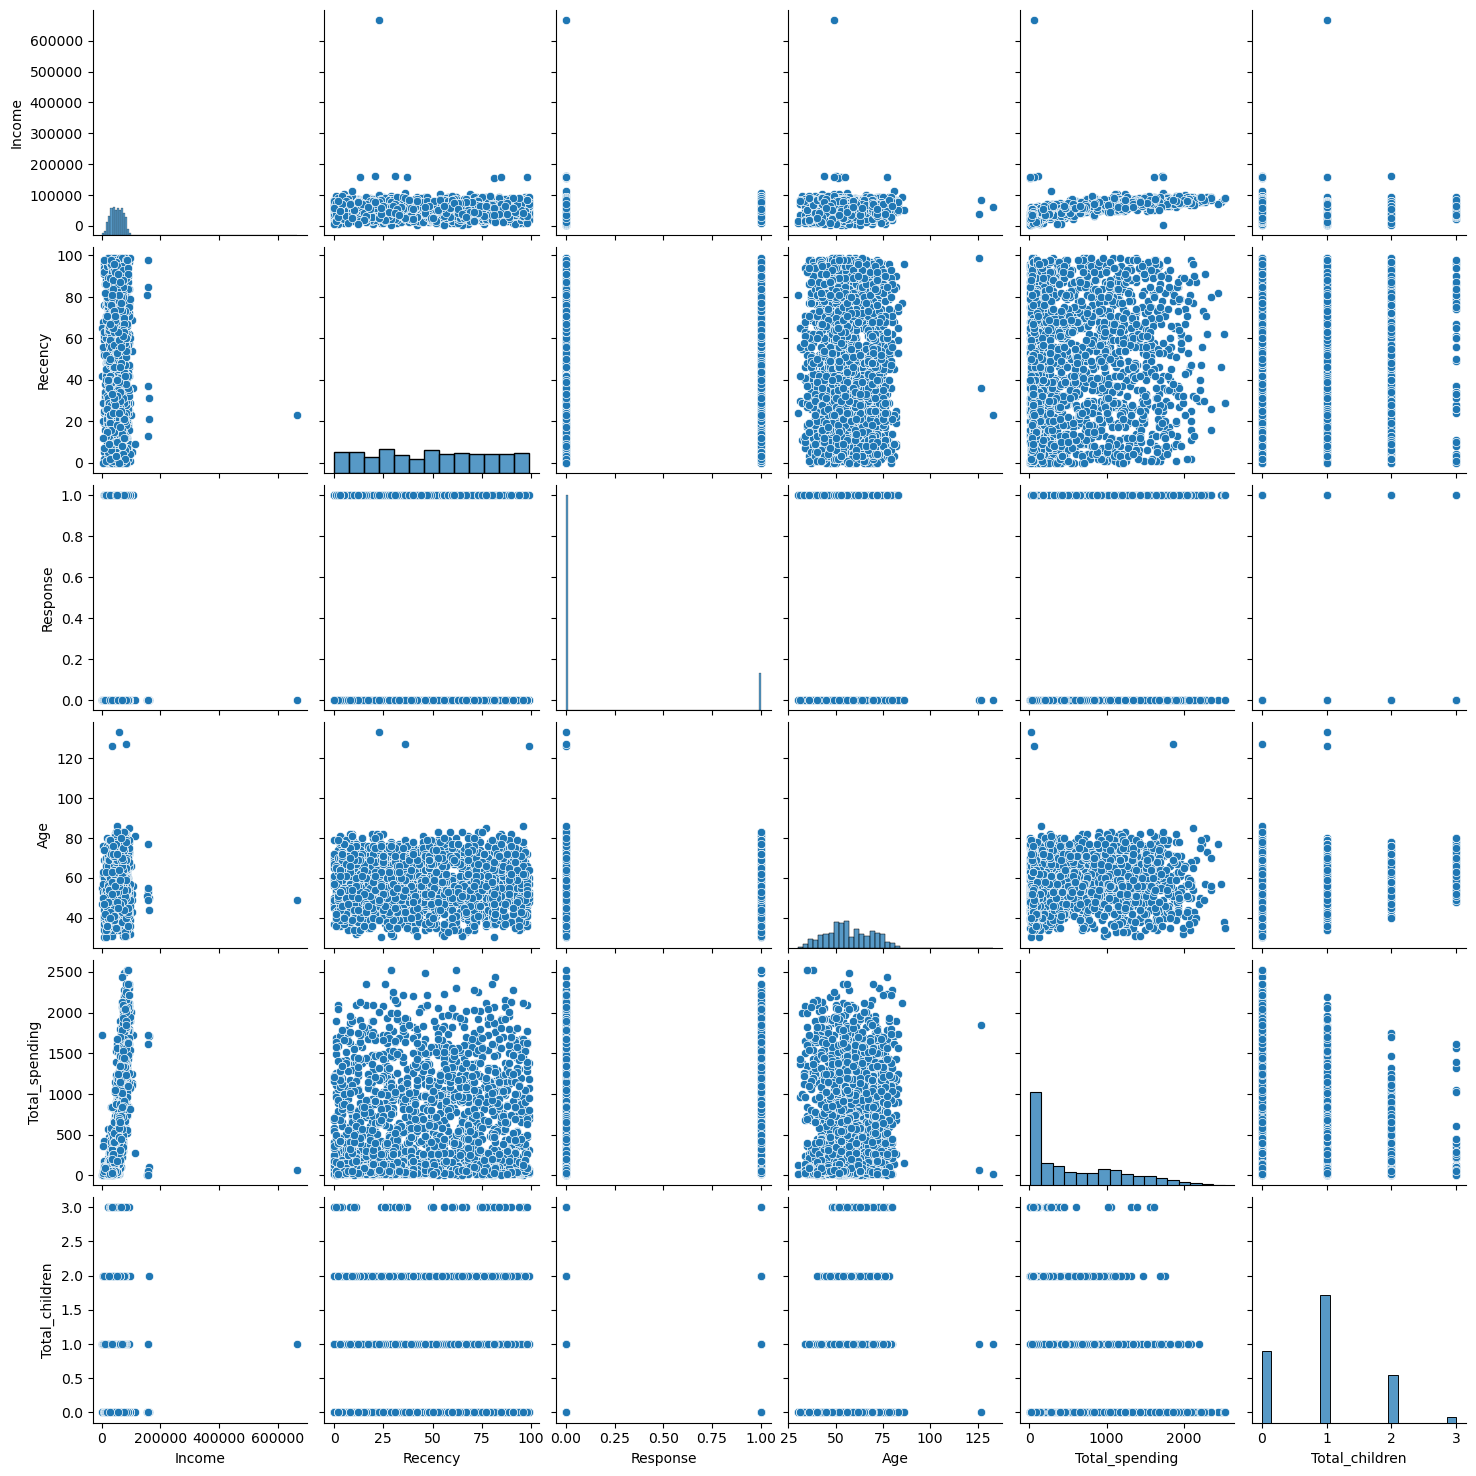

In [25]:
cols=["Income","Recency","Response","Age","Total_spending","Total_children"]

sns.pairplot(df_cleaned[cols])

In [26]:
# removing outlier
print("data with outliers :",len(df_cleaned))

df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]

print("data without outliers :",len(df_cleaned))


data with outliers : 2240
data without outliers : 2236


# HEATMAP

In [27]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

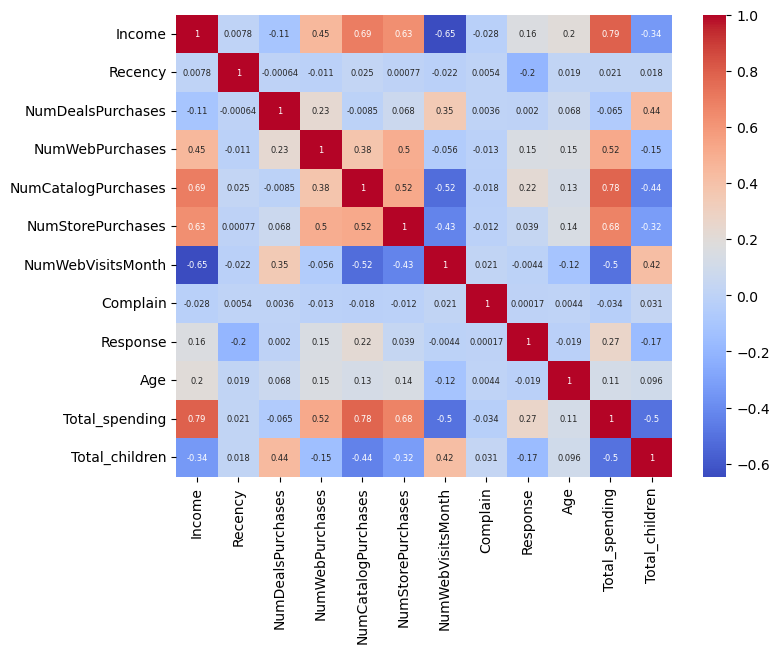

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [29]:
df_cleaned.shape

(2236, 15)

In [30]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,Partner


# ENCODING

In [31]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder() # no need to add dropfirst=true in clustering dataset

cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])


In [32]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [33]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [34]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=True)

In [35]:
df_encoded.shape

(2236, 18)

In [36]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,0.0,1.0


# SCALING

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
X=df_encoded

In [39]:
# from chat gpt
timedelta_cols = df_encoded.select_dtypes(include=['timedelta']).columns

for col in timedelta_cols:
    df_encoded[col] = df_encoded[col].dt.total_seconds()
# from chat gpt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# VISUALIZE

In [40]:
X_scaled.shape

(2236, 18)

In [41]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

In [42]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

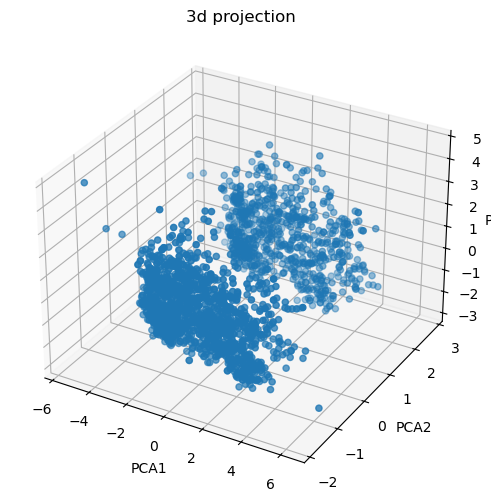

In [43]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d") 

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")


# K VALUE
## 1. ELBOW METHOD

In [44]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [45]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [46]:
optimal_k=knee.elbow

In [47]:
print("optimal k :",optimal_k)

optimal k : 4


Text(0, 0.5, 'wcss')

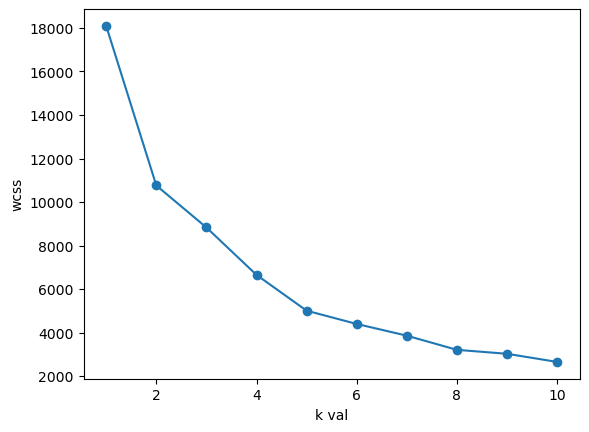

In [48]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k val")
plt.ylabel("wcss")

## 2. silhouette score

In [49]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

from sklearn.metrics import silhouette_score

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'silhouette_score')

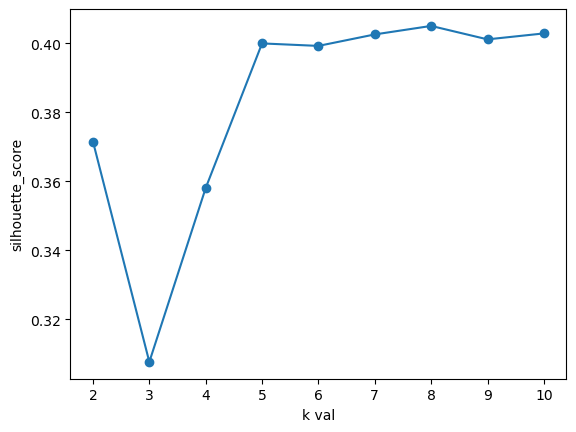

In [50]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k val")
plt.ylabel("silhouette_score")

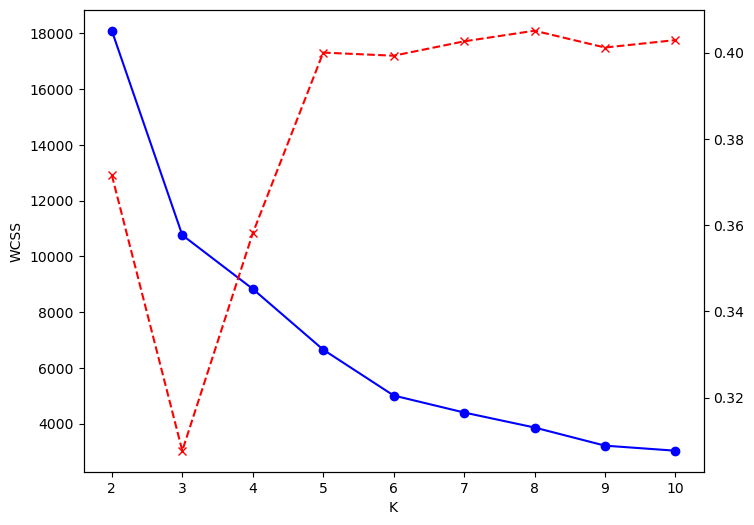

In [52]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_label("SS")

# CLUSTERING

In [68]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


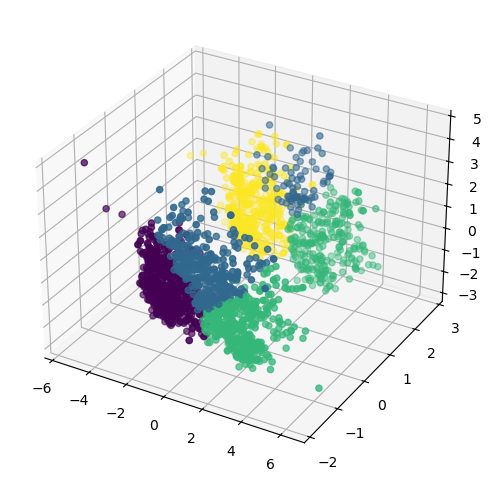

In [70]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d") 

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [76]:
from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

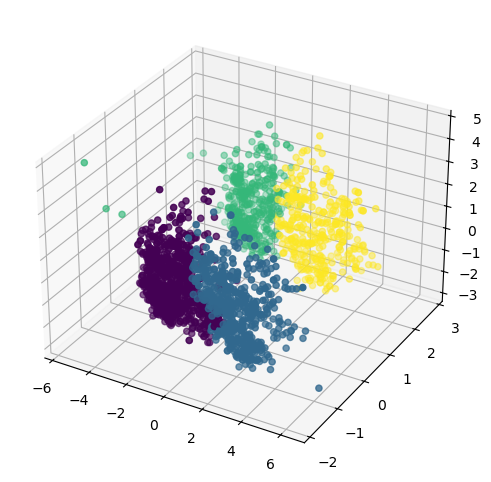

In [77]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d") 
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [87]:
df_cleaned.drop("labels",axis=1)
X["Clusters"]=labels_agg


In [88]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,57283200.0,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,9763200.0,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,26956800.0,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,12009600.0,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,13910400.0,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

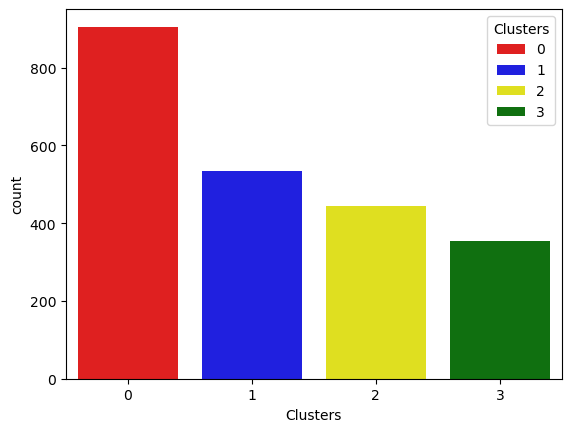

In [89]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["Clusters"],palette=pal,hue=X["Clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

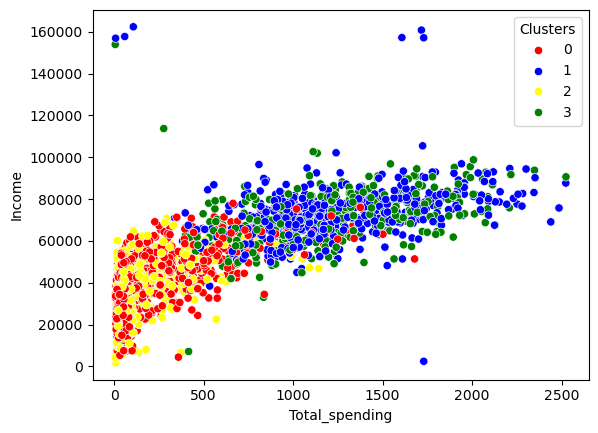

In [90]:
# income and spending patterns

sns.scatterplot(x=X["Total_spending"],y=X["Income"],hue=X["Clusters"],palette=pal)

In [92]:
# cluster summary
cluster_summary=X.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customers_Tenure_Days  Total_spending  \
Cl